Модель распространения акустического сигнала


Параметры симуляции:
  Частота дискретизации: 16000 Гц
  Длительность сигнала: 50 мс
  Количество микрофонов: 8
  Шаг решетки: 50 см
  Угол источника: 30°
  Расстояние до источника: 3.0 м
  Отношение сигнал/шум: 20 дБ

1. Генерация гармонического сигнала (440 Гц)
2. Создание линейной микрофонной решетки
   Координаты микрофонов: ['-0.175', '-0.125', '-0.075', '-0.025', '0.025', '0.075', '0.125', '0.175']
3. Расчет временных задержек
   Задержки в отсчетах: ['-4.1', '-2.9', '-1.8', '-0.6', '0.6', '1.8', '2.9', '4.1']
4. Формирование сигналов на микрофонах
   Размерность X: (8, 800)

5. Построение графиков


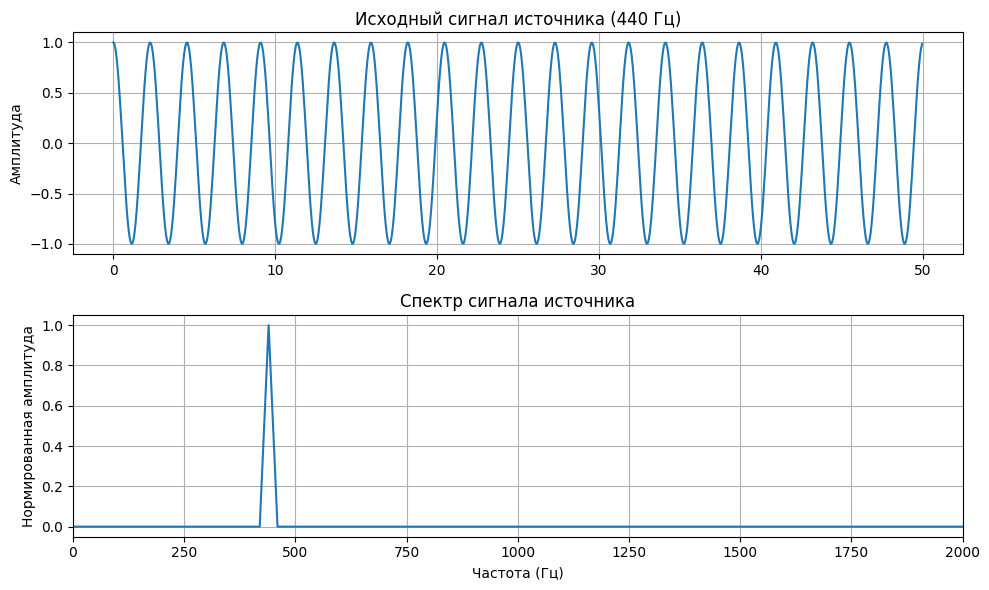

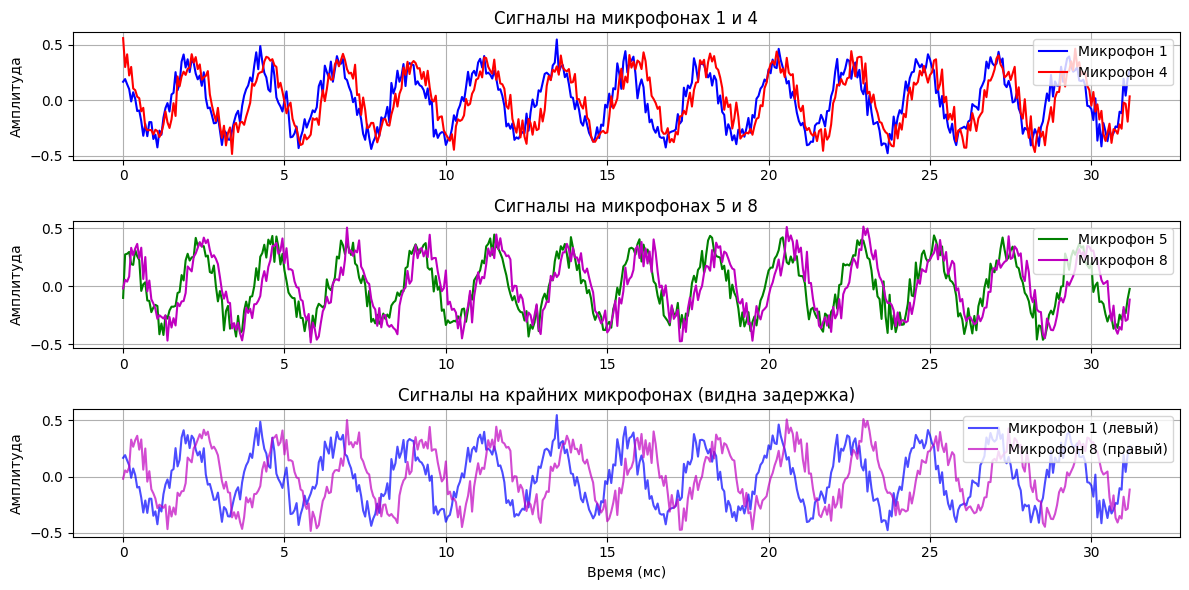

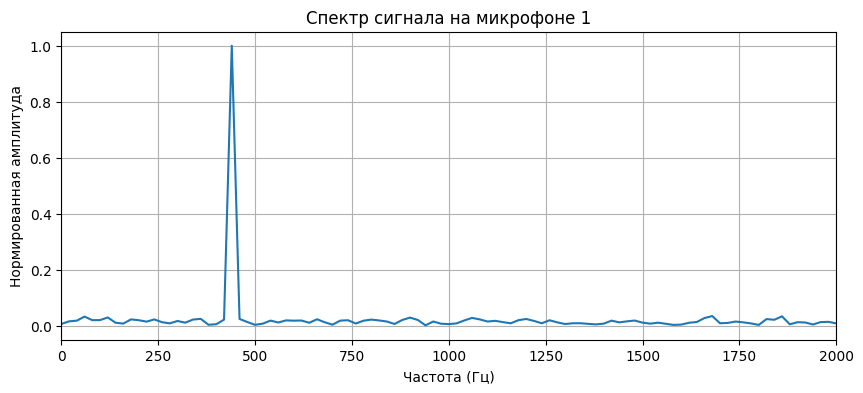

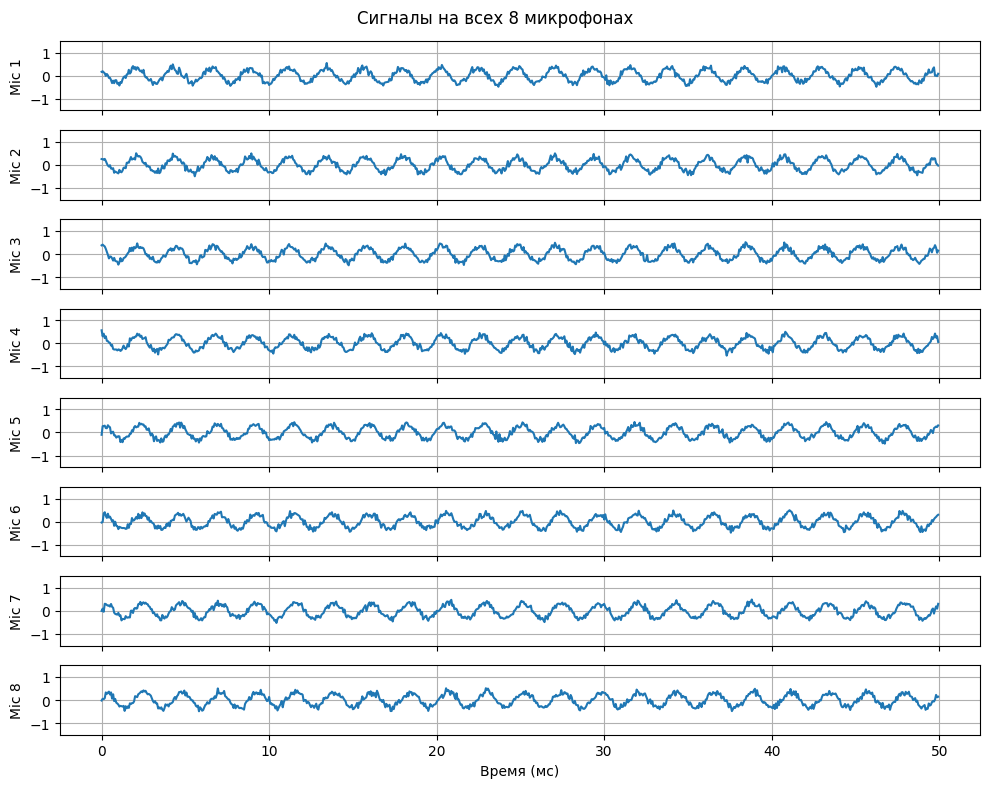

Симуляция завершена



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Генерация сигналов источников

def generate_harmonic_signal(fs, T, f0, A=1.0, phi0=0):
    """Генерация гармонического сигнала"""
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t + phi0)
    return t, s

def generate_wideband_signal(fs, T, f_min, f_max, order=4):
    """Генерация широкополосного сигнала"""
    t = np.arange(0, T, 1/fs)
    np.random.seed(42)  # для воспроизводимости
    white_noise = np.random.randn(len(t))
    white_noise = white_noise / np.std(white_noise)
    nyquist = fs / 2
    low = f_min / nyquist
    high = f_max / nyquist
    print(f"  f_min={f_min} Гц, f_max={f_max} Гц")
    print(f"  Нормированные: low={low:.3f}, high={high:.3f}")
    b, a = butter(order, [low, high], btype='band')
    s = filtfilt(b, a, white_noise)
    s = s / np.sqrt(np.mean(s**2))
    return t, s

def generate_impulse_signal(fs, T, fc, sigma, t0, A=1.0):
    """Генерация импульсного сигнала"""
    t = np.arange(0, T, 1/fs)
    envelope = A * np.exp(-(t - t0)**2 / (2 * sigma**2))
    carrier = np.cos(2 * np.pi * fc * (t - t0))
    s = envelope * carrier
    return t, s

# 2. Модель микрофонной решетки

def get_uniform_linear_array(M, delta_d=0.05):
    """Линейная равномерная решетка"""
    d = (np.arange(M) - (M - 1) / 2) * delta_d
    mic_positions = np.vstack([d, np.zeros(M), np.zeros(M)])
    return mic_positions, d

def compute_delays(d, theta, c=340, fs=None):
    """Расчет временных задержек"""
    theta_rad = np.deg2rad(theta)
    tau = d * np.sin(theta_rad) / c
    if fs is not None:
        tau_samps = tau * fs
        return tau, tau_samps
    return tau

def generate_array_signals(s, t, d, theta, R=3.0, SNR_dB=20, c=340, fs=None):
    """Генерация сигналов на решетке"""
    M = len(d)
    L = len(s)
    tau, tau_samps = compute_delays(d, theta, c, fs)
    delay_samples = np.round(tau_samps).astype(int)
    attenuation = 1.0 / R

    X = np.zeros((M, L))
    for m in range(M):
        s_delayed = np.roll(s, delay_samples[m])
        if delay_samples[m] > 0:
            s_delayed[:delay_samples[m]] = 0
        elif delay_samples[m] < 0:
            s_delayed[delay_samples[m]:] = 0

        signal_power = np.mean(s_delayed**2)
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = attenuation * s_delayed + noise
    return X

# 3. Визуализация

def plot_array_signals(X, t, title="Сигналы на микрофонах"):
    """Визуализация сигналов на всех микрофонах"""
    M = X.shape[0]
    fig, axes = plt.subplots(M, 1, figsize=(10, 8), sharex=True)
    for m in range(M):
        axes[m].plot(t[:1000] * 1000, X[m, :1000])
        axes[m].set_ylabel(f'Mic {m+1}')
        axes[m].grid(True)
        axes[m].set_ylim([-1.5, 1.5])
    axes[-1].set_xlabel('Время (мс)')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_spectrum(signal, fs, title="Спектр сигнала"):
    """Визуализация спектра"""
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1/fs)
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, fft_vals / np.max(fft_vals))
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Нормированная амплитуда')
    plt.title(title)
    plt.grid(True)
    plt.xlim(0, 2000)
    plt.show()

# 4. Демонстрационная симуляция

def run_simulation():
    """Запуск симуляции для получения графиков"""
    print("Модель распространения акустического сигнала")
    print()

    # параметры моделирования
    fs = 16000          # частота дискретизации (Гц)
    T = 0.05            # длительность сигнала (с)
    M = 8               # количество микрофонов
    delta_d = 0.05      # расстояние между микрофонами (м)
    theta = 30          # угол источника (градусы)
    R = 3.0             # расстояние до источника (м)
    SNR_dB = 20         # отношение сигнал/шум (дБ)

    print(f"\nПараметры симуляции:")
    print(f"  Частота дискретизации: {fs} Гц")
    print(f"  Длительность сигнала: {T*1000:.0f} мс")
    print(f"  Количество микрофонов: {M}")
    print(f"  Шаг решетки: {delta_d*1000:.0f} см")
    print(f"  Угол источника: {theta}°")
    print(f"  Расстояние до источника: {R} м")
    print(f"  Отношение сигнал/шум: {SNR_dB} дБ")

    # 1. генерация сигнала источника
    print("\n1. Генерация гармонического сигнала (440 Гц)")
    t, s = generate_harmonic_signal(fs, T, f0=440)

    # 2. создание решетки
    print("2. Создание линейной микрофонной решетки")
    mic_positions, d = get_uniform_linear_array(M, delta_d)
    print(f"   Координаты микрофонов: {[f'{x:.3f}' for x in d]}")

    # 3. расчет задержек
    print(f"3. Расчет временных задержек")
    tau, tau_samps = compute_delays(d, theta, fs=fs)
    print(f"   Задержки в отсчетах: {[f'{x:.1f}' for x in tau_samps]}")

    # 4. генерация сигналов на решетке
    print("4. Формирование сигналов на микрофонах")
    X = generate_array_signals(s, t, d, theta, R, SNR_dB, fs=fs)
    print(f"   Размерность X: {X.shape}")

    # 5. визуализация
    print("\n5. Построение графиков")

    # рис. 1: исходный сигнал и его спектр
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    axes[0].plot(t * 1000, s)
    axes[0].set_ylabel('Амплитуда')
    axes[0].set_title('Исходный сигнал источника (440 Гц)')
    axes[0].grid(True)

    fft_vals = np.abs(np.fft.rfft(s))
    freqs = np.fft.rfftfreq(len(s), 1/fs)
    axes[1].plot(freqs, fft_vals / np.max(fft_vals))
    axes[1].set_xlabel('Частота (Гц)')
    axes[1].set_ylabel('Нормированная амплитуда')
    axes[1].set_title('Спектр сигнала источника')
    axes[1].grid(True)
    axes[1].set_xlim(0, 2000)
    plt.tight_layout()
    plt.show()

    # рис. 2: сигналы на микрофонах
    fig, axes = plt.subplots(3, 1, figsize=(12, 6))

    axes[0].plot(t[:500] * 1000, X[0, :500], 'b-', label='Микрофон 1')
    axes[0].plot(t[:500] * 1000, X[3, :500], 'r-', label='Микрофон 4')
    axes[0].set_ylabel('Амплитуда')
    axes[0].set_title('Сигналы на микрофонах 1 и 4')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t[:500] * 1000, X[4, :500], 'g-', label='Микрофон 5')
    axes[1].plot(t[:500] * 1000, X[7, :500], 'm-', label='Микрофон 8')
    axes[1].set_ylabel('Амплитуда')
    axes[1].set_title('Сигналы на микрофонах 5 и 8')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t[:500] * 1000, X[0, :500], 'b-', alpha=0.7)
    axes[2].plot(t[:500] * 1000, X[7, :500], 'm-', alpha=0.7)
    axes[2].set_xlabel('Время (мс)')
    axes[2].set_ylabel('Амплитуда')
    axes[2].set_title('Сигналы на крайних микрофонах (видна задержка)')
    axes[2].legend(['Микрофон 1 (левый)', 'Микрофон 8 (правый)'])
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    # рис. 3: спектр сигнала на микрофоне
    plot_spectrum(X[0, :], fs, title="Спектр сигнала на микрофоне 1")

    # рис. 4: все сигналы микрофонов
    plot_array_signals(X, t, title="Сигналы на всех 8 микрофонах")

    print("Симуляция завершена")
    print()
    return X, t, d

# 5. Запуск

if __name__ == "__main__":
    X, t, d = run_simulation()